In [1]:
import sys
import os
# Add the project root directory to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from scripts.utils import get_time_series, get_timestamp_index, cleaning_data, feature_engineering, model_errors, plot_prediction, calculate_errors

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import logging
from datetime import datetime
random.seed(42)         # Python built-in random module
np.random.seed(42)

In [3]:
# 로깅 설정
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(f"regression_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"),
        logging.StreamHandler()  # 콘솔에도 출력
    ]
)
logger = logging.getLogger(__name__)

# 데이터 로드
logger.info("데이터 로드 시작")

2025-04-08 18:08:12,406 - INFO - 데이터 로드 시작


In [4]:
raw_data = pd.read_csv('../raw_data_20250403.csv')
data = get_timestamp_index(raw_data)
cleaned_region = cleaning_data(data,'Seoul')
cleaned_feature_added = feature_engineering(cleaned_region)

/Volumes/SUNSE/projects/building-ml-pipeline/scripts/utils.py:70: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_resampled[numeric_time_features] = data_resampled[numeric_time_features].interpolate(method='time')
/Volumes/SUNSE/projects/building-ml-pipeline/scripts/utils.py:71: FutureWarning: DataFrame.interpolate with method=bfill is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_resampled[categorical_date_features] = data_resampled[categorical_date_features].interpolate(method='bfill')
/Volumes/SUNSE/projects/building-ml-pipeline/scripts/utils.py:74: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

In [5]:
cleaned_feature_added.columns

Index(['PTY', 'REH', 'RN1', 'T1H', 'WSD', 'delay_hours', 'base_date', 'year',
       'month', 'day', 'day_of_week', 'is_holiday', 'hour', 'nx', 'ny',
       'admin_district_code', 'sin_hour', 'cos_hour', 'is_weekend',
       'day_of_week_encoded', 'PTY_lag1', 'PTY_lag2', 'delay_hours_lag1',
       'delay_hours_lag2'],
      dtype='object')

In [6]:
# 'base_date', day_of_week removed
features=['PTY', 'REH', 'RN1', 'T1H', 'WSD',  'day',  'hour', 
        'sin_hour', 'cos_hour', 'is_weekend',
       'day_of_week_encoded','PTY_lag1', 'PTY_lag2', 'delay_hours_lag1',
       'delay_hours_lag2']
X  = cleaned_feature_added[features]
y = np.log1p(cleaned_feature_added['delay_hours'])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

In [8]:
models = {
    "LinearRegression": LinearRegression(),
    "XGBoostRegressor": XGBRegressor(n_estimators=200,max_depth=5, learning_rate=0.01, enable_categorical=True),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=5),
}

In [9]:

# results = {}
predicted_series = {}
importance={}
results = {name: [] for name in models.keys()}
tscv = TimeSeriesSplit(n_splits=5)
for name, model in models.items():
    for train_idx, test_idx, in tscv.split(X):
        X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]
        logger.info(f"{name} 모델 학습 시작")
        try:
            model.fit(X_train_cv, y_train_cv)
            logger.info(f"{name} 모델 학습 완료")
            
            if name == 'LinearRegression':
                importance['lr_importance'] = np.abs(model.coef_)
            if name == 'XGBoostRegressor':
                importance['xgb_importance'] = model.feature_importances_
            if name == 'RandomForest':
                importance['rf_importance'] = model.feature_importances_

            y_pred_cv = model.predict(X_test_cv)
            y_pred_cv_original = np.expm1(y_pred_cv)
            y_test_cv_original = np.expm1(y_test_cv)
            errors = calculate_errors(y_test_cv_original,y_pred_cv_original)
            results[name].append(errors)

            # predicted_series[f'y_pred_{name}'] = y_pred_cv

        except Exception as e:
            logger.error(f"{name} 모델 처리 중 오류: {e}")

2025-04-08 18:08:12,489 - INFO - LinearRegression 모델 학습 시작
2025-04-08 18:08:12,492 - INFO - LinearRegression 모델 학습 완료
2025-04-08 18:08:12,495 - INFO - LinearRegression 모델 학습 시작
2025-04-08 18:08:12,496 - INFO - LinearRegression 모델 학습 완료
2025-04-08 18:08:12,499 - INFO - LinearRegression 모델 학습 시작
2025-04-08 18:08:12,500 - INFO - LinearRegression 모델 학습 완료
2025-04-08 18:08:12,502 - INFO - LinearRegression 모델 학습 시작
2025-04-08 18:08:12,503 - INFO - LinearRegression 모델 학습 완료
2025-04-08 18:08:12,505 - INFO - LinearRegression 모델 학습 시작
2025-04-08 18:08:12,506 - INFO - LinearRegression 모델 학습 완료
2025-04-08 18:08:12,508 - INFO - XGBoostRegressor 모델 학습 시작
2025-04-08 18:08:12,695 - INFO - XGBoostRegressor 모델 학습 완료
2025-04-08 18:08:12,699 - INFO - XGBoostRegressor 모델 학습 시작
2025-04-08 18:08:12,901 - INFO - XGBoostRegressor 모델 학습 완료
2025-04-08 18:08:12,905 - INFO - XGBoostRegressor 모델 학습 시작
2025-04-08 18:08:13,104 - INFO - XGBoostRegressor 모델 학습 완료
2025-04-08 18:08:13,107 - INFO - XGBoostRegressor 모델 학습 

In [10]:
mse=[]
mae=[]
rmse=[]
r2=[]
for item in results['XGBoostRegressor']:
    mse.append(item['mse'])
    mae.append(item['mae'])
    rmse.append(item['rmse'])
    r2.append(item['r2'])


In [11]:
np.mean(mse), np.mean(mae), np.mean(rmse), np.mean(r2) # lr

(np.float64(0.009574508369810216),
 np.float64(0.06463743139604085),
 np.float64(0.09206582055164535),
 np.float64(-0.0498626499095514))

In [12]:
np.mean(mse), np.mean(mae), np.mean(rmse), np.mean(r2) #xgb

(np.float64(0.009574508369810216),
 np.float64(0.06463743139604085),
 np.float64(0.09206582055164535),
 np.float64(-0.0498626499095514))

In [13]:
np.mean(mse), np.mean(mae), np.mean(rmse), np.mean(r2) #rf

(np.float64(0.009574508369810216),
 np.float64(0.06463743139604085),
 np.float64(0.09206582055164535),
 np.float64(-0.0498626499095514))

In [14]:
pd.DataFrame({
    'Feature': features,
    'Importance': importance['lr_importance']
}).sort_values(by='Importance', ascending=False)

,Feature,Importance
13,delay_hours_lag1,0.266809
0,PTY,0.248801
2,RN1,0.130070
12,PTY_lag2,0.065251
14,delay_hours_lag2,0.050020
11,PTY_lag1,0.012143
7,sin_hour,0.007104
9,is_weekend,0.004391
10,day_of_week_encoded,0.001878
3,T1H,0.000830


In [15]:
pd.DataFrame({
    'Feature': features,
    'Importance': importance['xgb_importance']
}).sort_values(by='Importance', ascending=False)

,Feature,Importance
0,PTY,0.620879
3,T1H,0.151521
7,sin_hour,0.037608
10,day_of_week_encoded,0.036311
13,delay_hours_lag1,0.029044
9,is_weekend,0.024111
6,hour,0.020508
1,REH,0.019046
14,delay_hours_lag2,0.018107
8,cos_hour,0.017072


In [16]:
pd.DataFrame({
    'Feature': features,
    'Importance': importance['rf_importance']
}).sort_values(by='Importance', ascending=False)

,Feature,Importance
0,PTY,0.388566
3,T1H,0.305509
13,delay_hours_lag1,0.172862
14,delay_hours_lag2,0.034837
1,REH,0.031703
4,WSD,0.014854
6,hour,0.012795
7,sin_hour,0.010754
8,cos_hour,0.010220
5,day,0.007529


In [17]:
predicted_series = {}
importance={}

for name, model in models.items():
    logger.info(f"{name} 모델 학습 시작")
    try:
        model.fit(X_train, y_train)
        logger.info(f"{name} 모델 학습 완료")
        
        if name == 'LinearRegression':
            importance['lr_importance'] = np.abs(model.coef_)
        if name == 'XGBoostRegressor':
            importance['xgb_importance'] = model.feature_importances_
        if name == 'RandomForest':
            importance['rf_importance'] = model.feature_importances_

        y_pred = model.predict(X_test)
        predicted_series[f'y_pred_{name}'] = y_pred

    except Exception as e:
        logger.error(f"{name} 모델 처리 중 오류: {e}")

2025-04-08 18:08:14,250 - INFO - LinearRegression 모델 학습 시작
2025-04-08 18:08:14,325 - INFO - LinearRegression 모델 학습 완료
2025-04-08 18:08:14,326 - INFO - XGBoostRegressor 모델 학습 시작
2025-04-08 18:08:14,542 - INFO - XGBoostRegressor 모델 학습 완료
2025-04-08 18:08:14,544 - INFO - RandomForest 모델 학습 시작
2025-04-08 18:08:14,692 - INFO - RandomForest 모델 학습 완료


In [18]:
predicted_series['y_pred_LinearRegression'] = np.expm1(predicted_series['y_pred_LinearRegression'])
predicted_series['y_pred_XGBoostRegressor'] = np.expm1(predicted_series['y_pred_XGBoostRegressor'])
predicted_series['y_pred_RandomForest'] = np.expm1(predicted_series['y_pred_RandomForest'])
y_test_exp = np.expm1(y_test)

In [19]:
# plot_prediction(predicted_series, y_test_exp)

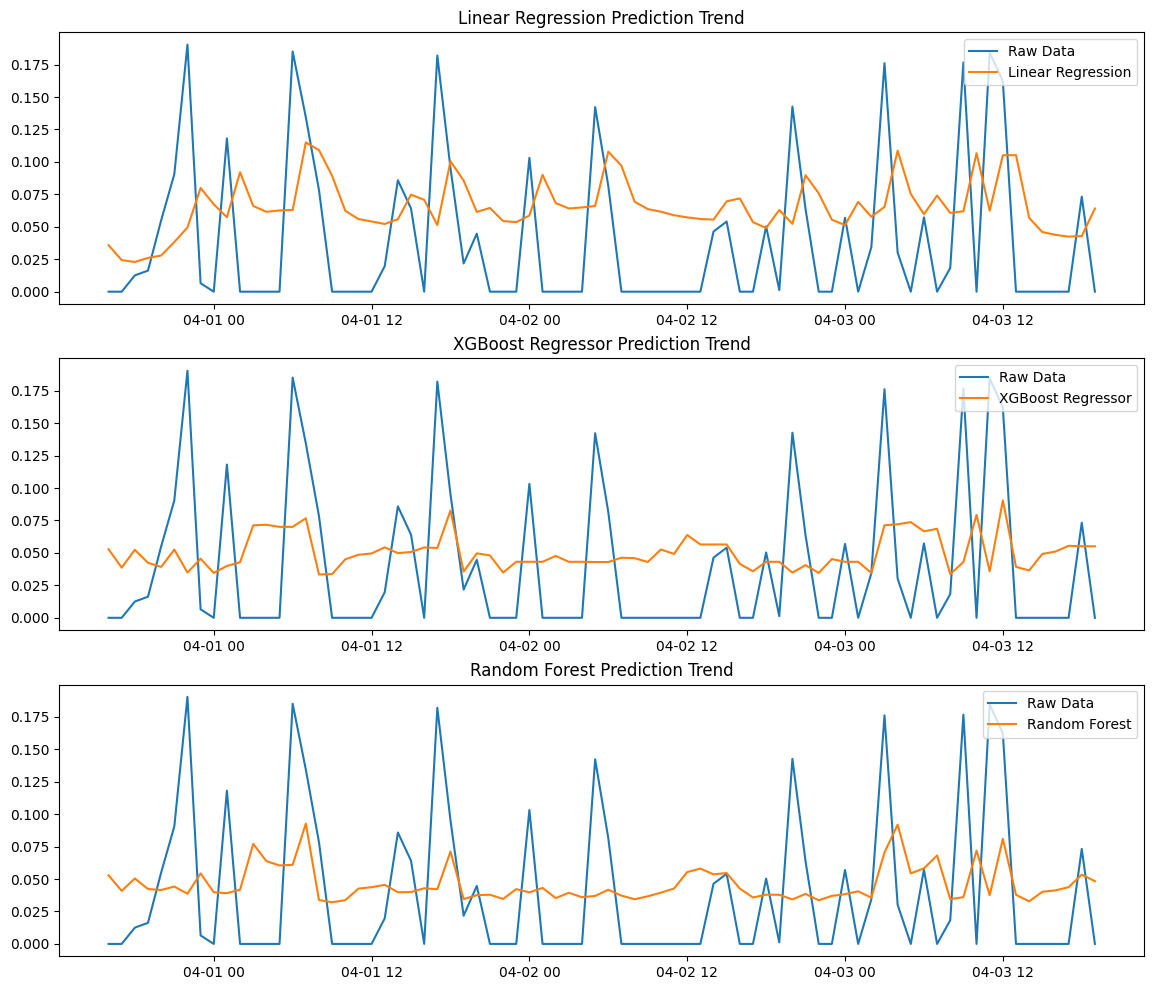

In [20]:
plot_prediction(predicted_series, y_test_exp)